# Toy Sentiment Task: Word Combinations

Train a tiny MLP to classify combinations of six words as negative (0) or
positive (1), according to the majority sentiment. Ties are excluded.

Run the entire notebook to train, evaluate, inspect hidden activations, and
ablate neurons. The dataset is generated locally; no download is needed.


In [1]:
from itertools import combinations
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
torch.manual_seed(42)

import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


### Get the Toy Dataset

Positive words: `good`, `great`, `happy`. Negative words: `bad`, `awful`, `sad`.
Generate all combinations of one, three, or five distinct words: **32 examples**.
Odd lengths avoid ties. Label each combination by the majority of its words.

Each input is a six-number word-count vector, with columns in the order shown above.
Words appear at most once, so counts are either zero or one. Word order is ignored.

Keep all six single words in training so every word has a known sentiment.
For each class and each length of three or five words, hold out one combination.
This gives **28 training examples and 4 validation examples**, balanced by label.
No validation combination appears in training. Validation checks generalization
across combinations of known words, not across new vocabulary or realistic language.


In [2]:
words = ["good", "great", "happy", "bad", "awful", "sad"]
class_names = ["negative", "positive"]
word_to_index = {word: index for index, word in enumerate(words)}

def encode_texts(texts):
    features = torch.zeros((len(texts), len(words)))
    for row, text in enumerate(texts):
        for word in text.split():
            features[row, word_to_index[word]] += 1
    return features

train_data, val_data = [], []
for length in [1, 3, 5]:
    groups = {0: [], 1: []}
    for indices in combinations(range(len(words)), length):
        positive_count = sum(index < 3 for index in indices)
        label = int(positive_count > length / 2)
        text = " ".join(words[index] for index in indices)
        groups[label].append((text, label))
    for examples in groups.values():
        random.shuffle(examples)
        if length == 1:
            train_data.extend(examples)
        else:
            val_data.append(examples[0])
            train_data.extend(examples[1:])

random.shuffle(train_data)
train_texts, train_labels = zip(*train_data)
val_texts, val_labels = zip(*val_data)
X_train = encode_texts(train_texts)
X_val = encode_texts(val_texts)
y_train = torch.tensor(train_labels, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)

print(f"Training examples: {len(train_data)}, validation examples: {len(val_data)}")
print("Input columns:", words)


Training examples: 28, validation examples: 4
Input columns: ['good', 'great', 'happy', 'bad', 'awful', 'sad']


### Build and Train a Tiny MLP

The network has six inputs, four hidden neurons, and two output scores:
`[negative, positive]`. Train for 100 epochs using cross-entropy loss,
then check accuracy on the held-out combinations.


In [3]:
class SentimentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(6, 4)
        self.fc2 = nn.Linear(4, 2)

    def forward(self, x):
        hidden = F.relu(self.fc1(x))
        return self.fc2(hidden), hidden

model = SentimentMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(100):
    logits, _ = model(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(model)
print(f"Final training loss: {losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    val_logits, _ = model(X_val)
    val_predictions = val_logits.argmax(dim=1)
    val_accuracy = (val_predictions == y_val).float().mean().item()
print(f"Validation accuracy: {val_accuracy:.0%} ({len(val_data)} held-out combinations)")


SentimentMLP(
  (fc1): Linear(in_features=6, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=2, bias=True)
)
Final training loss: 0.0001
Validation accuracy: 100% (4 held-out combinations)


### Input and Output Examples

| Word combination | Input vector | Expected output | Reason |
| --- | --- | --- | --- |
| good happy | [1, 0, 1, 0, 0, 0] | 1 (positive) | 2 positive, 0 negative |
| bad sad | [0, 0, 0, 1, 0, 1] | 0 (negative) | 0 positive, 2 negative |
| good bad happy | [1, 0, 1, 1, 0, 0] | 1 (positive) | 2 positive, 1 negative |
| bad good sad | [1, 0, 0, 1, 0, 1] | 0 (negative) | 1 positive, 2 negative |

The two-word rows illustrate the rule; the generated dataset uses lengths 1, 3,
and 5. Reordering words produces the same vector.

The model produces two scores per input. `argmax` selects the larger score's index:
`0` for negative or `1` for positive. The cell below prints actual predictions
for the four held-out validation combinations, followed by the examples above.
A four-example validation set is only a small demonstration of generalization.


In [4]:
example_texts = ["good happy", "bad sad", "good bad happy", "bad good sad"]
example_labels = [1, 0, 1, 0]

model.eval()
with torch.no_grad():
    example_logits, _ = model(encode_texts(example_texts))
    example_predictions = example_logits.argmax(dim=1)

print("Held-out validation combinations:")
for text, expected, predicted in zip(val_texts, y_val, val_predictions):
    print(f"{text}: expected {class_names[expected.item()]}, "
          f"predicted {class_names[predicted.item()]}")

print("\nIllustrative combinations:")
for text, expected, predicted in zip(example_texts, example_labels, example_predictions):
    print(f"{text}: expected {class_names[expected]}, "
          f"predicted {class_names[predicted.item()]}")


Held-out validation combinations:
happy awful sad: expected negative, predicted negative
good happy awful: expected positive, predicted positive
good great bad awful sad: expected negative, predicted negative
good great happy awful sad: expected positive, predicted positive

Illustrative combinations:
good happy: expected positive, predicted positive
bad sad: expected negative, predicted negative
good bad happy: expected positive, predicted positive
bad good sad: expected negative, predicted negative


### Print Activations of a sample input

In [5]:
sample_text = "good bad happy"
sample_input = encode_texts([sample_text])
model.eval()
with torch.no_grad():
    logits, hidden = model(sample_input)
print("Sample text:", sample_text)
print("Input vector:", sample_input)
print("Hidden activations:", hidden)
print("Output scores [negative, positive]:", logits)
print("Prediction:", class_names[logits.argmax(dim=1).item()])


Sample text: good bad happy
Input vector: tensor([[1., 0., 1., 1., 0., 0.]])
Hidden activations: tensor([[2.3239, 1.9895, 0.5314, 0.0000]])
Output scores [negative, positive]: tensor([[-4.3861,  5.2115]])
Prediction: positive


### Average Hidden Activations by Sentiment


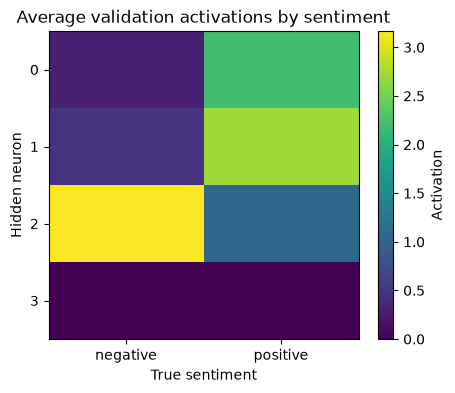

In [6]:
with torch.no_grad():
    _, val_hidden = model(X_val)
    avg_activations = torch.stack([
        val_hidden[y_val == label].mean(dim=0) for label in range(2)
    ])

plt.figure(figsize=(5, 4))
plt.imshow(avg_activations.T.numpy(), aspect="auto", cmap="viridis")
plt.xticks([0, 1], class_names)
plt.yticks(range(model.fc1.out_features))
plt.xlabel("True sentiment")
plt.ylabel("Hidden neuron")
plt.title("Average validation activations by sentiment")
plt.colorbar(label="Activation")
plt.show()


#### Reading the Activation Plot

Brighter cells indicate stronger average activation. Compare each neuron's
response to positive and negative combinations. A dark neuron may be inactive
on these inputs. With only four validation examples, these averages are limited;
activation differences alone do not prove that a neuron controls the prediction.


### Neuron Ablation (single neuron)

In [7]:
test_text = "good bad happy"
test_input = encode_texts([test_text])
neuron_to_zero = 3

model.eval()
with torch.no_grad():
    baseline_logits, hidden = model(test_input)
    baseline_probability = baseline_logits.softmax(dim=1)[0, 1].item()
    ablated_hidden = hidden.clone()
    ablated_hidden[:, neuron_to_zero] = 0
    modified_logits = model.fc2(ablated_hidden)
    modified_probability = modified_logits.softmax(dim=1)[0, 1].item()

print("Input:", test_text, "| Expected: positive")
print("Baseline prediction:", class_names[baseline_logits.argmax(dim=1).item()])
print("Ablated prediction:", class_names[modified_logits.argmax(dim=1).item()])
print(f"Positive probability: {baseline_probability:.4f} -> {modified_probability:.4f}")
print(f"Change after zeroing neuron {neuron_to_zero}: "
      f"{modified_probability - baseline_probability:+.4f}")


Input: good bad happy | Expected: positive
Baseline prediction: positive
Ablated prediction: positive
Positive probability: 0.9999 -> 0.9999
Change after zeroing neuron 3: +0.0000


#### Reading the Ablation Result

Zeroing a hidden activation tests its contribution to this particular prediction.
A probability change can reveal an effect even when the predicted label stays the
same. No change on one input does not establish that the neuron is unused overall.


### Neuron Ablation (sweep of neurons)

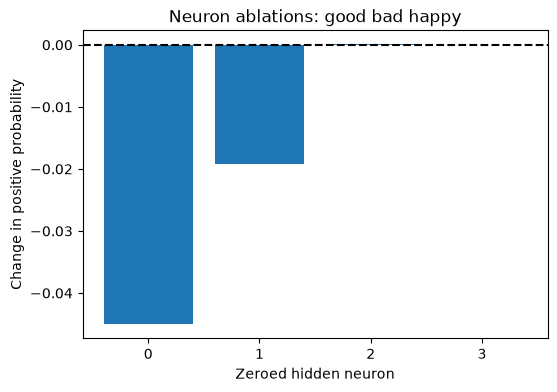

Neuron 0: change in positive probability -0.0451
Neuron 1: change in positive probability -0.0192
Neuron 2: change in positive probability +0.0001
Neuron 3: change in positive probability +0.0000


In [8]:
neuron_indices = list(range(model.fc1.out_features))
signed_deltas = []
with torch.no_grad():
    for index in neuron_indices:
        ablated_hidden = hidden.clone()
        ablated_hidden[:, index] = 0
        ablated_logits = model.fc2(ablated_hidden)
        probability = ablated_logits.softmax(dim=1)[0, 1].item()
        signed_deltas.append(probability - baseline_probability)

plt.figure(figsize=(6, 4))
plt.bar(neuron_indices, signed_deltas)
plt.axhline(0, color="black", linestyle="--")
plt.xticks(neuron_indices)
plt.xlabel("Zeroed hidden neuron")
plt.ylabel("Change in positive probability")
plt.title(f"Neuron ablations: {test_text}")
plt.show()
for index, delta in zip(neuron_indices, signed_deltas):
    print(f"Neuron {index}: change in positive probability {delta:+.4f}")


#### Reading the Ablation Sweep

A negative change means zeroing the neuron reduced positive probability; a positive
change means it increased positive probability. Compare magnitudes to see which
neurons affect this example most. Try other inputs before drawing general conclusions.
